In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [3]:
df=pd.DataFrame(pd.read_excel(r'C:\Users\vaagd\Desktop\IDA project trial\google playstore\googleplaystore_edited.xlsx'))
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Unnamed: 13,Sentiment
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,01-07-18,1.0.0,4.0.3 and up,NaN,1
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,01-15-18,2.0.0,4.0.3 and up,NaN,2
2,"U Launcher Lite â FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,08-01-18,1.2.4,4.0.3 and up,NaN,3
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,06-08-18,Varies with device,4.2 and up,NaN,3
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,06-20-18,1.1,4.4 and up,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5395,Abs workout - 21 Day Fitness Challenge,HEALTH_AND_FITNESS,4.8,18604,15M,"1,000,000+",Free,0,Everyone,Health & Fitness,2018-02-05 00:00:00,1.0.0.9,4.1 and up,NaN,3
5396,Ladies' Ab Workout FREE,HEALTH_AND_FITNESS,4.0,12906,8.5M,"1,000,000+",Free,0,Everyone,Health & Fitness,2012-08-10 00:00:00,1.01,2.1 and up,NaN,3
5397,30-Day Ab Challenge Tracker,HEALTH_AND_FITNESS,3.5,224,371k,"10,000+",Free,0,Everyone,Health & Fitness,2014-09-07 00:00:00,1.2.6,4.1 and up,NaN,3
5398,Universal AC Remote Control,TOOLS,3.8,40934,5.2M,"1,000,000+",Free,0,Everyone,Tools,07-28-18,acremotecontrol18,4.0.3 and up,NaN,3


In [4]:
android_version_counts = df['Android Ver'].value_counts()
android_version_counts

4.1 and up            1159
Varies with device    1051
4.0.3 and up           746
4.4 and up             565
4.0 and up             554
5.0 and up             362
2.3 and up             252
4.2 and up             197
4.3 and up             102
3.0 and up              87
2.3.3 and up            87
2.2 and up              63
2.1 and up              43
6.0 and up              36
7.0 and up              22
1.6 and up              14
5.1 and up              11
3.2 and up              11
1.5 and up               8
4.4W and up              5
8.0 and up               4
3.1 and up               4
2.0 and up               3
7.1 and up               3
2.0.1 and up             3
4.0.3 - 7.1.1            2
5.0 - 8.0                2
7.0 - 7.1.1              1
4.1 - 7.1.1              1
Name: Android Ver, dtype: int64

In [5]:
most_used_version = android_version_counts.idxmax()
most_used_count = android_version_counts.max()

print(f"The most used Android version is {most_used_version} with {most_used_count} occurrences.")

The most used Android version is 4.1 and up with 1159 occurrences.


In [6]:
df.isnull().sum()

App                  0
Category             0
Rating             224
Reviews              0
Size                 0
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          2
Android Ver          2
Unnamed: 13       5400
Sentiment          248
dtype: int64

In [7]:
df.isnull().sum().sum()

5876

In [8]:
len(df)

5400

In [9]:
df.isnull().sum()/len(df)*100

App                 0.000000
Category            0.000000
Rating              4.148148
Reviews             0.000000
Size                0.000000
Installs            0.000000
Type                0.000000
Price               0.000000
Content Rating      0.000000
Genres              0.000000
Last Updated        0.000000
Current Ver         0.037037
Android Ver         0.037037
Unnamed: 13       100.000000
Sentiment           4.592593
dtype: float64

In [10]:
df = df.drop(["Unnamed: 13","Android Ver"], axis=1)

In [11]:
df.mean(numeric_only=True)

Rating          4.247952
Reviews    832500.584259
dtype: float64

In [12]:
df.median(numeric_only=True)

Rating         4.3
Reviews    22505.5
dtype: float64

In [13]:
df["Rating"].value_counts()

4.4    722
4.5    681
4.3    655
4.2    593
4.6    538
4.1    420
4.0    289
4.7    276
3.9    180
3.8    136
4.8    134
3.7    110
3.6     70
3.5     62
3.4     45
3.3     40
5.0     36
3.1     33
4.9     29
3.0     29
3.2     23
2.9     11
2.5     10
2.8      9
2.7      8
1.9      7
2.6      6
2.2      6
2.4      6
1.8      4
1.0      2
2.3      2
1.7      2
2.0      1
1.6      1
Name: Rating, dtype: int64

In [14]:
df["Reviews"].value_counts()

0         78
2         31
3         28
1         26
6         20
          ..
32506      1
70747      1
358817     1
15403      1
6973       1
Name: Reviews, Length: 3887, dtype: int64

In [15]:
df['Rating'].fillna(df['Rating'].median(),inplace=True)

In [16]:
df['Sentiment'].fillna(df['Sentiment'].median(),inplace=True)

In [17]:
df['Current Ver'] = pd.to_numeric(df['Current Ver'], errors='coerce')

In [18]:
df['Current Ver'].fillna(df['Current Ver'].median(), inplace=True)

In [19]:
df.isnull().sum()/len(df)*100

App               0.0
Category          0.0
Rating            0.0
Reviews           0.0
Size              0.0
Installs          0.0
Type              0.0
Price             0.0
Content Rating    0.0
Genres            0.0
Last Updated      0.0
Current Ver       0.0
Sentiment         0.0
dtype: float64

In [20]:
df.duplicated().sum()

105

In [21]:
df=df.drop_duplicates()

In [22]:
df.to_csv('googleplaystore_clean.csv',index=False)

In [23]:
df.duplicated().sum()

0

In [24]:
df['Rating'].mean()

4.250009442870632

In [25]:
df['Reviews'].mean()

837518.1299338999

In [26]:
df['Rating'].median()

4.3

In [27]:
df['Reviews'].median()

22018.0

In [28]:
df['Rating'].mode()

0    4.3
Name: Rating, dtype: float64

In [29]:
df['Reviews'].mode()

0    0
Name: Reviews, dtype: int64

In [30]:
df['Rating'].max()-df['Rating'].min()

4.0

In [31]:
df['Reviews'].max()-df['Reviews'].min()

78158306

In [32]:
df['Rating'].var()

0.16489563648051972

In [33]:
df['Reviews'].var()

16955785153401.695

In [34]:
df['Rating'].std()

0.40607343729985557

In [35]:
df['Reviews'].std()

4117740.2969834916

In [36]:
df.groupby(['Category'])["Reviews"].agg(["mean","median","max","min","var","std"]).round(2)

,mean,median,max,min,var,std
Category,,,,,,
ART_AND_DESIGN,28223.13,845.0,295237,13,5.071228e+09,71212.55
AUTO_AND_VEHICLES,17467.39,1981.0,271920,2,2.223175e+09,47150.55
BEAUTY,8426.32,473.0,113715,9,4.231286e+08,20570.09
BOOKS_AND_REFERENCE,227810.94,2724.0,2915189,0,4.023762e+11,634331.34
BUSINESS,95914.88,14760.0,1279184,7,5.938302e+10,243686.31
COMICS,98607.09,2012.0,1013944,15,7.284557e+10,269899.19
COMMUNICATION,3804952.64,305218.0,69119316,0,1.142162e+14,10687198.40
DATING,22835.78,852.0,516801,0,4.144476e+09,64377.61
EDUCATION,257549.78,29917.5,6290507,11,1.025325e+12,1012583.26


In [72]:
df.groupby(["App","Category","Genres"])["Rating"].agg(["mean","median","max","min","var","std"]).round(2)

,,,mean,median,max,min,var,std
App,Category,Genres,,,,,,
- Free Comics - Comic Apps,COMICS,Comics,3.5,3.5,3.5,3.5,NaN,NaN
.R,TOOLS,Tools,4.5,4.5,4.5,4.5,0.0,0.0
/u/app,COMMUNICATION,Communication,4.7,4.7,4.7,4.7,0.0,0.0
10 Best Foods for You,HEALTH_AND_FITNESS,Health & Fitness,4.0,4.0,4.0,4.0,NaN,NaN
100+ C Programs,FAMILY,Education,4.2,4.2,4.2,4.2,NaN,NaN
...,...,...,...,...,...,...,...,...
ä¹æNAVITIMEãTimetable & Route Search in Japan Tokyo,MAPS_AND_NAVIGATION,Maps & Navigation,4.4,4.4,4.4,4.4,NaN,NaN
"æ¼«å Comics - Manga,Novel and Stories",COMICS,Comics,4.1,4.1,4.1,4.1,NaN,NaN
ð I'm rich,LIFESTYLE,Lifestyle,3.8,3.8,3.8,3.8,NaN,NaN


In [38]:
type(df["Rating"].mean())

numpy.float64

In [39]:
type(df["Category"].mode())

pandas.core.series.Series

In [40]:
df.groupby(["App"])["Genres"].agg(pd.Series.mode)

App
- Free Comics - Comic Apps                                             Comics
.R                                                                      Tools
/u/app                                                          Communication
10 Best Foods for You                                        Health & Fitness
100+ C Programs                                                     Education
                                                                  ...        
ä¹æNAVITIMEãTimetable & Route Search in Japan Tokyo    Maps & Navigation
æ¼«å Comics - Manga,Novel and Stories                                Comics
ð I'm rich                                                       Lifestyle
ð WhatsLov: Smileys of love, stickers and GIF                       Social
ð¥ Football Wallpapers 4K | Full HD Backgrounds ð          Entertainment
Name: Genres, Length: 4051, dtype: object

In [41]:
df.groupby(['App'],as_index=False,dropna=False)["Reviews"].agg(pd.Series.mode)

,App,Reviews
0,- Free Comics - Comic Apps,115
1,.R,259
2,/u/app,573
3,10 Best Foods for You,2490
4,100+ C Programs,20
...,...,...
4046,ä¹æNAVITIMEãTimetable & Route Search in J...,50459
4047,"æ¼«å Comics - Manga,Novel and Stories",12088
4048,ð I'm rich,718
4049,"ð WhatsLov: Smileys of love, stickers and GIF",22098


In [42]:
df.groupby("App")["Reviews"].agg(["min", "max"]).round(2)

,min,max
App,,
- Free Comics - Comic Apps,115,115
.R,259,259
/u/app,573,573
10 Best Foods for You,2490,2490
100+ C Programs,20,20
...,...,...
ä¹æNAVITIMEãTimetable & Route Search in Japan Tokyo,50459,50459
"æ¼«å Comics - Manga,Novel and Stories",12088,12088
ð I'm rich,718,718


In [43]:
df.groupby("App")[["Rating","Reviews"]].agg(["mean", "max"])

Rating       Reviews       
                                                     mean  max     mean    max
App                                                                           
- Free Comics - Comic Apps                            3.5  3.5    115.0    115
.R                                                    4.5  4.5    259.0    259
/u/app                                                4.7  4.7    573.0    573
10 Best Foods for You                                 4.0  4.0   2490.0   2490
100+ C Programs                                       4.2  4.2     20.0     20
...                                                   ...  ...      ...    ...
ä¹æNAVITIMEãTimetable & Route Search in Ja...    4.4  4.4  50459.0  50459
æ¼«å Comics - Manga,Novel and Stories               4.1  4.1  12088.0  12088
ð I'm rich                                         3.8  3.8    718.0    718
ð WhatsLov: Smileys of love, stickers and GIF      4.6  4.6  22098.0  22098
ð¥ Football Wallpapers 4K | Full HD Backgroun...    4.7  4.7  11661.0  11661

[4051 rows x 4 columns]

In [44]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Sentiment'],
      dtype='object')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5295 entries, 0 to 5399
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             5295 non-null   object 
 1   Category        5295 non-null   object 
 2   Rating          5295 non-null   float64
 3   Reviews         5295 non-null   int64  
 4   Size            5295 non-null   object 
 5   Installs        5295 non-null   object 
 6   Type            5295 non-null   object 
 7   Price           5295 non-null   object 
 8   Content Rating  5295 non-null   object 
 9   Genres          5295 non-null   object 
 10  Last Updated    5295 non-null   object 
 11  Current Ver     5295 non-null   float64
 12  Sentiment       5295 non-null   object 
dtypes: float64(2), int64(1), object(10)
memory usage: 579.1+ KB


In [46]:
df["Rating"].describe()

count    5295.000000
mean        4.250009
std         0.406073
min         1.000000
25%         4.100000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [47]:
df["Rating"].quantile(0.35)

4.2

In [48]:
df["Reviews"].describe()

count    5.295000e+03
mean     8.375181e+05
std      4.117740e+06
min      0.000000e+00
25%      1.245000e+03
50%      2.201800e+04
75%      1.870040e+05
max      7.815831e+07
Name: Reviews, dtype: float64

In [49]:
df["Reviews"].quantile()

22018.0

In [50]:
df.kurt()

C:\Users\vaagd\AppData\Local\Temp\ipykernel_1500\1257127604.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.kurt()


Rating            7.563086
Reviews         172.323461
Current Ver    1437.061479
Sentiment              NaN
dtype: float64

C:\Users\vaagd\AppData\Local\Temp\ipykernel_1500\637012864.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Rating"],color='lightgreen')


<Axes: xlabel='Rating', ylabel='Density'>

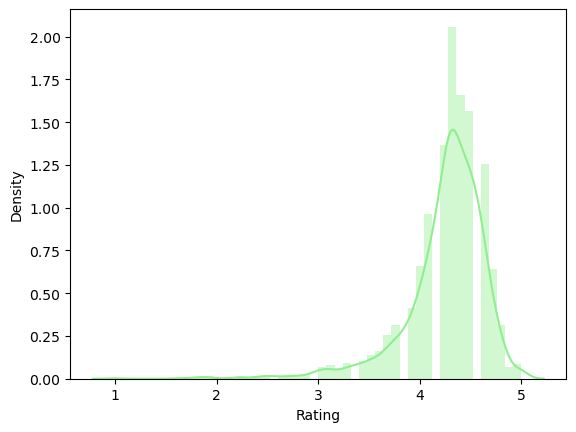

In [51]:
sns.distplot(df["Rating"],color='lightgreen')

In [52]:
df.mean()

C:\Users\vaagd\AppData\Local\Temp\ipykernel_1500\3698961737.py:1: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.mean()


Rating              4.250009
Reviews        837518.129934
Current Ver     17198.667029
dtype: float64

In [53]:
df.median()

C:\Users\vaagd\AppData\Local\Temp\ipykernel_1500\530051474.py:1: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.median()


Rating             4.300000
Reviews        22018.000000
Current Ver        1.915903
Sentiment          2.000000
dtype: float64

In [54]:
df.mode()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Sentiment
0,ROBLOX,FAMILY,4.3,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,08-03-18,1.915903,1


C:\Users\vaagd\AppData\Local\Temp\ipykernel_1500\1300913186.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Reviews"])


<Axes: xlabel='Reviews', ylabel='Density'>

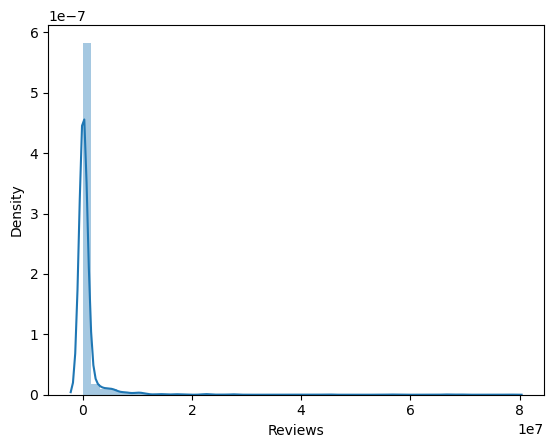

In [55]:
sns.distplot(df["Reviews"])

In [56]:
df.skew()

C:\Users\vaagd\AppData\Local\Temp\ipykernel_1500\1665899112.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.skew()


Rating         -2.052458
Reviews        11.768765
Current Ver    37.442161
Sentiment            NaN
dtype: float64

C:\Users\vaagd\AppData\Local\Temp\ipykernel_1500\3240183755.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Reviews"],color='red')


<Axes: xlabel='Reviews', ylabel='Density'>

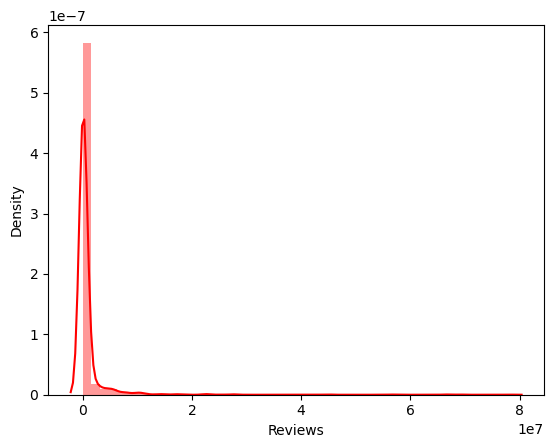

In [57]:
sns.distplot(df["Reviews"],color='red')

C:\Users\vaagd\AppData\Local\Temp\ipykernel_1500\1538456005.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Rating"],color='lightpink')


<Axes: xlabel='Rating', ylabel='Density'>

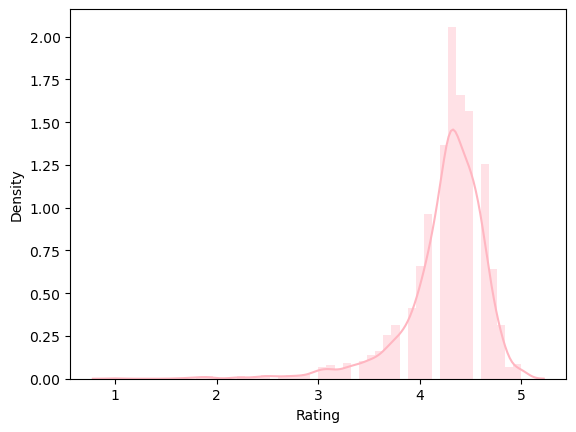

In [58]:
sns.distplot(df["Rating"],color='lightpink')

In [59]:
df.corr()

C:\Users\vaagd\AppData\Local\Temp\ipykernel_1500\1134722465.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Rating,Reviews,Current Ver
Rating,1.000000,0.078398,0.006068
Reviews,0.078398,1.000000,-0.005655
Current Ver,0.006068,-0.005655,1.000000


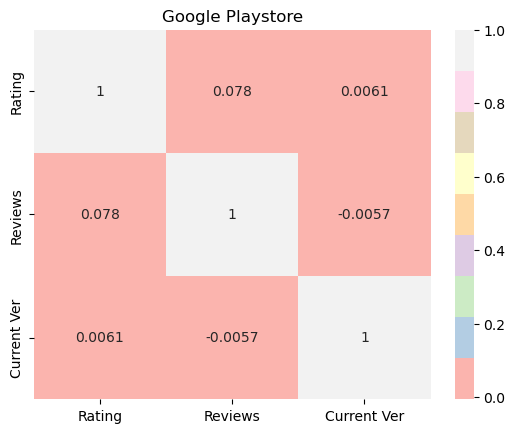

In [60]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap = 'Pastel1')
plt.title('Google Playstore')
plt.savefig('googleplaystore_heatmap')

In [61]:
box=pd.read_csv('googleplaystore_clean.csv')
box

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Sentiment
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,01-07-18,1.915903,1
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,01-15-18,1.915903,2
2,"U Launcher Lite â FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,08-01-18,1.915903,3
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,06-08-18,1.915903,3
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,06-20-18,1.100000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5290,Abs workout - 21 Day Fitness Challenge,HEALTH_AND_FITNESS,4.8,18604,15M,"1,000,000+",Free,0,Everyone,Health & Fitness,2018-02-05 00:00:00,1.915903,3
5291,Ladies' Ab Workout FREE,HEALTH_AND_FITNESS,4.0,12906,8.5M,"1,000,000+",Free,0,Everyone,Health & Fitness,2012-08-10 00:00:00,1.010000,3
5292,30-Day Ab Challenge Tracker,HEALTH_AND_FITNESS,3.5,224,371k,"10,000+",Free,0,Everyone,Health & Fitness,2014-09-07 00:00:00,1.915903,3
5293,Universal AC Remote Control,TOOLS,3.8,40934,5.2M,"1,000,000+",Free,0,Everyone,Tools,07-28-18,1.915903,3


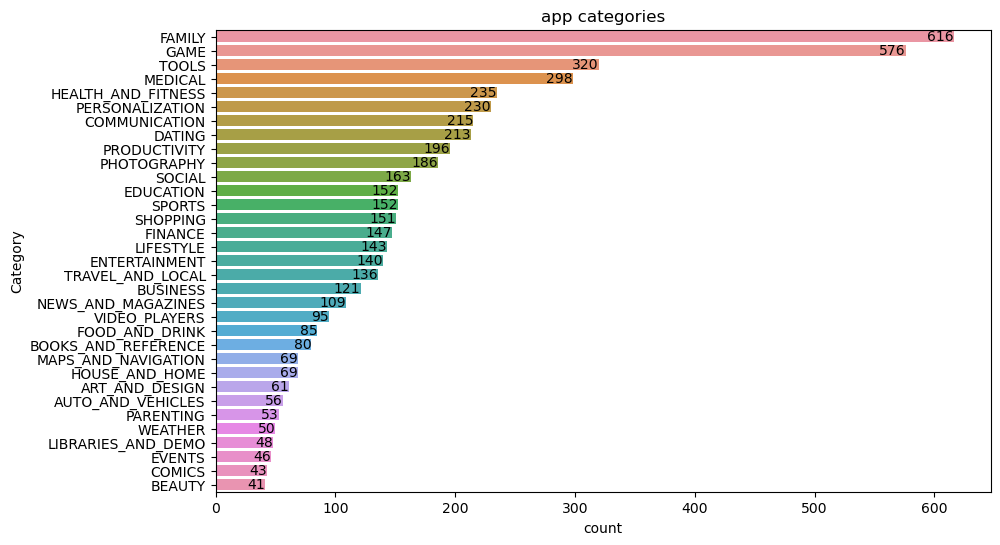

In [62]:
plt.figure(figsize=(10,6))
sns.countplot(df,y='Category',order = df['Category'].value_counts().index)
category_counts = df['Category'].value_counts()
for index, value in enumerate(category_counts):
    plt.text(value, index, str(value), ha='right', va='center')
plt.xlabel('count')
plt.ylabel('Category')
plt.title('app categories')
plt.savefig('googleplaystore.png')
plt.show()

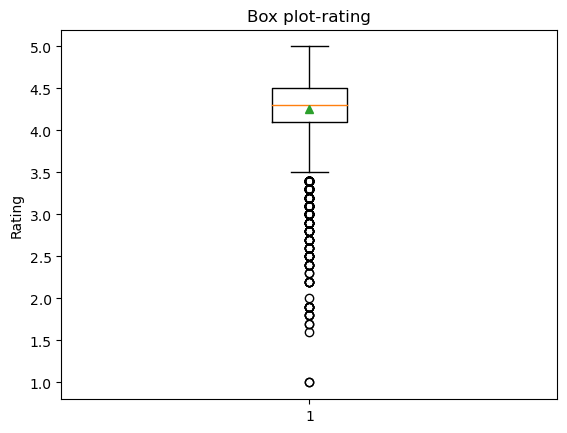

In [71]:
plt.boxplot(box['Rating'],vert=True,showmeans=True)
plt.ylabel('Rating')
plt.title('Box plot-rating')
plt.savefig('googleplaystore_box.png')
plt.show()

In [64]:
df_top_rated = df[df["Rating"] == 5.00]
df_top_rated = df_top_rated.drop(columns=["Genres", "Content Rating", "Price", "Type", "Size", "Category"])

most_reviews = df_top_rated["Reviews"].max()
most_reviews
highest_rated_app = df_top_rated[df_top_rated["Reviews"] == most_reviews]
df_top_rated.sort_values("Reviews", ascending=False).head(10)

,App,Rating,Reviews,Installs,Last Updated,Current Ver,Sentiment
1547,Eternal life,5.0,26,"1,000+",05-24-18,1.000000,2
1030,Prosperity,5.0,16,100+,07-09-18,1.140000,2
329,Hojiboy Tojiboyev Life Hacks,5.0,15,"1,000+",06-26-18,2.000000,1
636,Girls Live Talk - Free Text and Video Chat,5.0,6,100+,08-01-18,8.200000,0
2527,BP Journal - Blood Pressure Diary,5.0,6,"1,000+",05-25-18,1.915903,1
633,Spine- The dating app,5.0,5,500+,07-14-18,4.000000,0
640,Online Girls Chat Group,5.0,5,100+,08-02-18,8.200000,0
612,American Girls Mobile Numbers,5.0,5,"1,000+",07-17-18,3.000000,2
2450,Tablet Reminder,5.0,4,5+,08-03-18,1.000000,0
4539,R Programing Offline Tutorial,5.0,4,"1,000+",03-15-18,1.915903,3


C:\Users\vaagd\AppData\Local\Temp\ipykernel_1500\2469450945.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  dataframe.groupby(['App']).sum().plot(kind='pie', y='Reviews', autopct='%1.0f%%',colors=colors)


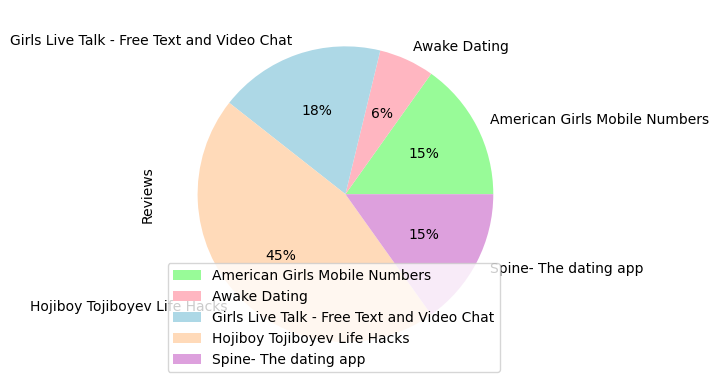

In [65]:
dataframe=df_top_rated.head(5)
colors=['palegreen','lightpink','lightblue','peachpuff','plum']
dataframe.groupby(['App']).sum().plot(kind='pie', y='Reviews', autopct='%1.0f%%',colors=colors)
plt.savefig('googleplaystore_pie.png')

In [66]:
import matplotlib.pyplot as plt 
%matplotlib inline 

In [67]:
data = pd.read_csv('googleplaystore_clean.csv')

In [68]:
freq_table = pd.crosstab(data['Rating'], 'Current Ver') 
freq_table.head(10)

col_0,Current Ver
Rating,
1.0,2
1.6,1
1.7,2
1.8,4
1.9,7
2.0,1
2.2,6
2.3,2
2.4,6


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_data